In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np # Import necessary functions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# fetch dataset
rt_iot2022 = fetch_ucirepo(id=942)

# data (as pandas dataframes)
X = rt_iot2022.data.features
y = rt_iot2022.data.targets

In [4]:
rt_iot2022.metadata

{'uci_id': 942,
 'name': 'RT-IoT2022 ',
 'repository_url': 'https://archive.ics.uci.edu/dataset/942/rt-iot2022',
 'data_url': 'https://archive.ics.uci.edu/static/public/942/data.csv',
 'abstract': 'The RT-IoT2022, a proprietary dataset derived from a real-time IoT infrastructure, is introduced as a comprehensive resource integrating a diverse range of IoT devices and sophisticated network attack methodologies. This dataset encompasses both normal and adversarial network behaviours, providing a general representation of real-world scenarios.\nIncorporating data from IoT devices such as ThingSpeak-LED, Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios involving Brute-Force SSH attacks, DDoS attacks using Hping and Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed perspective on the complex nature of network traffic. The bidirectional attributes of network traffic are meticulously captured using the Zeek network monitoring tool and the Flowmeter plugin. Researchers

In [5]:
rt_iot2022.variables

,name,role,type,demographic,description,units,missing_values
0,id.orig_p,Feature,Integer,None,None,None,no
1,id.resp_p,Feature,Integer,None,None,None,no
2,proto,Feature,Categorical,None,None,None,no
3,service,Feature,Continuous,None,None,None,no
4,flow_duration,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...
80,fwd_init_window_size,Feature,Integer,None,None,None,no
81,bwd_init_window_size,Feature,Integer,None,None,None,no
82,fwd_last_window_size,Feature,Integer,None,None,None,no
83,Attack_type,Target,Categorical,None,None,None,no


In [6]:
df=rt_iot2022.variables.copy()
df_reset=df.reset_index()
df_reset

,index,name,role,type,demographic,description,units,missing_values
0,0,id.orig_p,Feature,Integer,None,None,None,no
1,1,id.resp_p,Feature,Integer,None,None,None,no
2,2,proto,Feature,Categorical,None,None,None,no
3,3,service,Feature,Continuous,None,None,None,no
4,4,flow_duration,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...,...
80,80,fwd_init_window_size,Feature,Integer,None,None,None,no
81,81,bwd_init_window_size,Feature,Integer,None,None,None,no
82,82,fwd_last_window_size,Feature,Integer,None,None,None,no
83,83,Attack_type,Target,Categorical,None,None,None,no


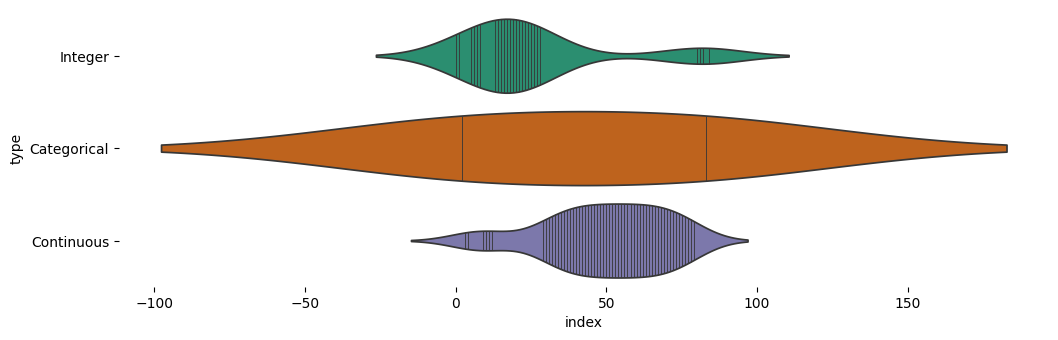

In [7]:
figsize = (12, 1.2 * len(df_reset['type'].unique()))
plt.figure(figsize=figsize)

# Use 'index' column for x-axis
sns.violinplot(df_reset, x='index', y='type', inner='stick', palette='Dark2', hue='type', legend=False)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.show()

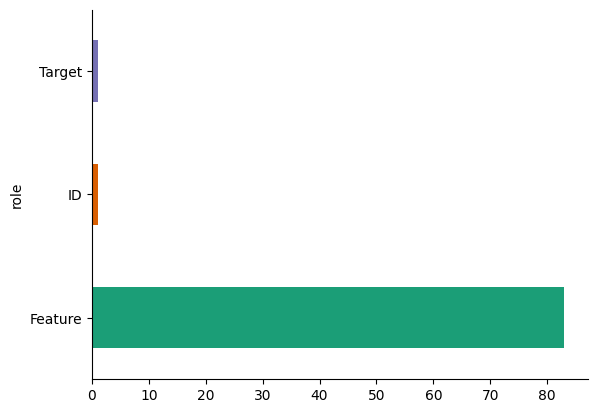

In [8]:
df_reset.groupby('role').size().plot(kind='barh',
                                     color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

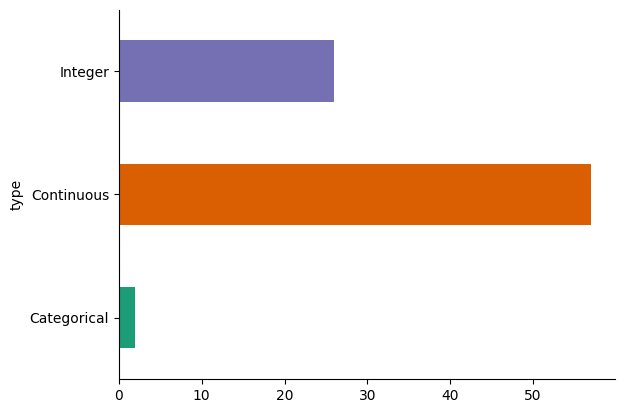

In [9]:
df_reset.groupby('type').size().plot(kind='barh',
                                     color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

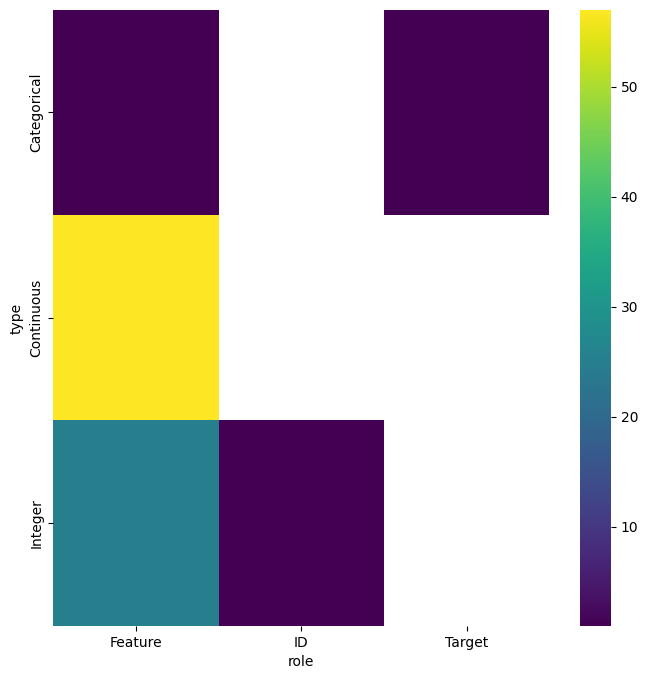

In [10]:
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['type'].value_counts()
    for x_label, grp in df_reset.groupby('role')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('role')
_ = plt.ylabel('type')

In [11]:
X.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,2087656.975,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502


In [12]:
y.head()

,Attack_type
0,MQTT_Publish
1,MQTT_Publish
2,MQTT_Publish
3,MQTT_Publish
4,MQTT_Publish


In [13]:
X.describe()

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,34639.258738,1014.305092,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,7.035683e+05,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,19070.620354,5256.371994,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,7.415634e+05,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,17702.000000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,1.490871e+02,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,37221.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,4.934475e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,50971.000000,21.000000,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,1.048576e+06,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,65535.000000,65389.000000,21728.335580,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,2.097152e+06,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


In [14]:
# Check for missing values
X.isnull().sum()

,0
id.orig_p,0
id.resp_p,0
proto,0
service,0
flow_duration,0
...,...
idle.avg,0
idle.std,0
fwd_init_window_size,0
bwd_init_window_size,0


In [15]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

# Identify non-numerical columns
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns

# Handle non-numerical columns (example: one-hot encoding)
X_train = pd.get_dummies(X_train, columns=non_numeric_cols)
X_test = pd.get_dummies(X_test, columns=non_numeric_cols)  # Apply same transformation to test set

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [17]:
# Evaluate the model
print("Random Forest Model Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.9978882391163093


In [18]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
                             precision    recall  f1-score   support

            ARP_poisioning       0.98      0.99      0.99      2306
            DDOS_Slowloris       0.99      0.97      0.98       154
             DOS_SYN_Hping       1.00      1.00      1.00     28409
              MQTT_Publish       1.00      1.00      1.00      1273
Metasploit_Brute_Force_SSH       1.00      0.64      0.78        11
             NMAP_FIN_SCAN       1.00      0.86      0.92         7
         NMAP_OS_DETECTION       1.00      1.00      1.00       622
             NMAP_TCP_scan       1.00      1.00      1.00       319
             NMAP_UDP_SCAN       0.99      0.99      0.99       750
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       582
               Thing_Speak       0.99      0.99      0.99      2424
                Wipro_bulb       1.00      0.94      0.97        79

                  accuracy                           1.00     36936
                 macro

In [19]:
# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define the model
dl_model = Sequential()
dl_model.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(1, activation='sigmoid'))  # Use 'softmax' if multiclass classification

# Compile the model
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model using the encoded target variable
dl_model.fit(X_train, y_train_encoded, epochs=20, batch_size=32, validation_data=(X_test, y_test_encoded))

# Evaluate the model
loss, accuracy = dl_model.evaluate(X_test, y_test_encoded)
print("Deep Learning Model Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.0045 - loss: -456481.5312 - val_accuracy: 0.0042 - val_loss: -1667212.2500
Epoch 2/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0044 - loss: -5004940.5000 - val_accuracy: 0.0042 - val_loss: -9501029.0000
Epoch 3/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.0044 - loss: -16918380.0000 - val_accuracy: 0.0042 - val_loss: -25687336.0000
Epoch 4/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0044 - loss: -38325332.0000 - val_accuracy: 0.0042 - val_loss: -52259352.0000
Epoch 5/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.0044 - loss: -71011864.0000 - val_accuracy: 0.0042 - val_loss: -91061296.0000
Epoch 6/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.0044 - loss: -117328952.0000 - val_accuracy: 0.0042 - val_loss: -144486688.0000
Epoch 7/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0044 - loss: -178978144.0000 - val_accuracy: 0.0042 - val_

In [20]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Convert y_test to a 1D array of labels if it's not already
if y_test.ndim != 1:
    y_test_1d = y_test.values.ravel()  # Convert to 1D NumPy array
else:
    y_test_1d = y_test

# Calculate ROC-AUC Score for multiclass
print("ROC-AUC Score:", roc_auc_score(y_test_1d, rf_model.predict_proba(X_test), multi_class='ovr'))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Model Accuracy: 0.9978882391163093
Classification Report:
                             precision    recall  f1-score   support

            ARP_poisioning       0.98      0.99      0.99      2306
            DDOS_Slowloris       0.99      0.97      0.98       154
             DOS_SYN_Hping       1.00      1.00      1.00     28409
              MQTT_Publish       1.00      1.00      1.00      1273
Metasploit_Brute_Force_SSH       1.00      0.64      0.78        11
             NMAP_FIN_SCAN       1.00      0.86      0.92         7
         NMAP_OS_DETECTION       1.00      1.00      1.00       622
             NMAP_TCP_scan       1.00      1.00      1.00       319
             NMAP_UDP_SCAN       0.99      0.99      0.99       750
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       582
               Thing_Speak       0.99      0.99      0.99      2424
                Wipro_bulb       1.00      0.94      0.97        79

                  accuracy               

In [21]:
# Convert y_train and y_test to numpy arrays and reshape
y_train_np = np.array(y_train).reshape(-1, 1)
y_test_np = np.array(y_test).reshape(-1, 1)

# Encode the target variable to one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False) # Changed sparse=False to sparse_output=False
y_train_encoded = onehot_encoder.fit_transform(y_train_np)
y_test_encoded = onehot_encoder.transform(y_test_np)

# Define the deep learning model
dl_model = Sequential()
dl_model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
dl_model.add(Dropout(0.5))  # Add dropout for regularization
dl_model.add(Dense(64, activation='relu'))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(y_train_encoded.shape[1], activation='softmax'))  # Multiclass classification

# Compile the model
dl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using the one-hot encoded target variable
dl_model.fit(X_train, y_train_encoded, epochs=20, batch_size=64, validation_data=(X_test, y_test_encoded))

# Evaluate the model
loss, accuracy = dl_model.evaluate(X_test, y_test_encoded)
y_pred_dl = dl_model.predict(X_test)

# Compute ROC-AUC Score
print("Deep Learning Model Accuracy:", accuracy)
print("ROC-AUC Score:", roc_auc_score(y_test_encoded, y_pred_dl, multi_class='ovr'))  # Use one-hot encoded y_test for ROC-AUC


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1347/1347 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9604 - loss: 0.1403 - val_accuracy: 0.9857 - val_loss: 0.0539
Epoch 2/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9834 - loss: 0.0540 - val_accuracy: 0.9853 - val_loss: 0.0401
Epoch 3/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0511 - val_accuracy: 0.9900 - val_loss: 0.0326
Epoch 4/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9897 - loss: 0.0391 - val_accuracy: 0.9907 - val_loss: 0.0277
Epoch 5/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9908 - loss: 0.0354 - val_accuracy: 0.9930 - val_loss: 0.0276
Epoch 6/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9921 - loss: 0.0336 - val_accuracy: 0.9936 - val_loss: 0.0239
Epoch 7/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9922 - loss: 0.0295 - val_accuracy: 0.9942 - val_loss: 0.0219
Epoch 8/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9926 - loss: 0.0237 - val_accurac

In [22]:
# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Model Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Model Accuracy: 0.9975362789690275
Classification Report:
                             precision    recall  f1-score   support

            ARP_poisioning       0.98      0.99      0.99      2306
            DDOS_Slowloris       0.99      1.00      1.00       154
             DOS_SYN_Hping       1.00      1.00      1.00     28409
              MQTT_Publish       1.00      1.00      1.00      1273
Metasploit_Brute_Force_SSH       0.89      0.73      0.80        11
             NMAP_FIN_SCAN       0.86      0.86      0.86         7
         NMAP_OS_DETECTION       1.00      1.00      1.00       622
             NMAP_TCP_scan       1.00      1.00      1.00       319
             NMAP_UDP_SCAN       0.98      0.99      0.98       750
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       582
               Thing_Speak       0.99      0.98      0.99      2424
                Wipro_bulb       0.93      0.94      0.93        79

                  accuracy               

In [23]:
# Extract the labels from the DataFrame as a 1D array
y_test_array = y_test.values.ravel()

# Set multi_class to 'ovr' for One-vs-Rest approach
print("Decision Tree ROC-AUC Score:",
      roc_auc_score(y_test_array, dt_model.predict_proba(X_test),
                    multi_class='ovr'))


Decision Tree ROC-AUC Score: 0.9780358670683736


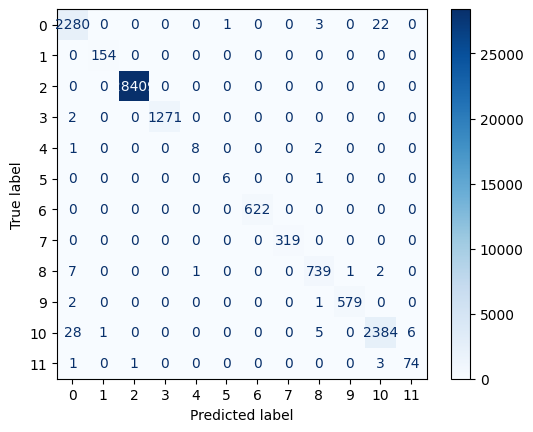

In [24]:
# Generate confusion matrix and plot it
cm = confusion_matrix(y_test, y_pred_dt) # Generate confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) # Create display object
disp.plot(cmap=plt.cm.Blues) # Plot confusion matrix
plt.show()

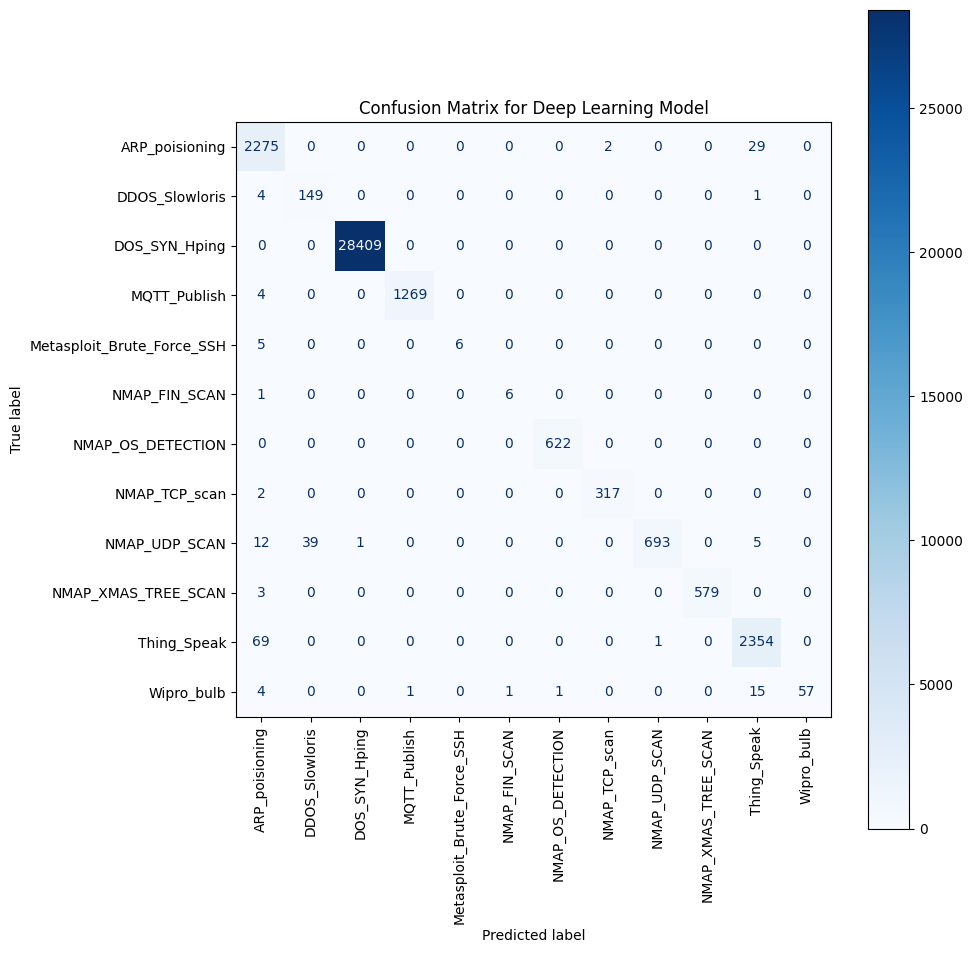

In [25]:
# Convert one-hot encoded y_test to class labels
y_true_dl = onehot_encoder.inverse_transform(y_test_encoded)

# Convert predicted probabilities to class labels
y_pred_dl_classes = np.argmax(y_pred_dl, axis=1)
y_pred_dl_labels = onehot_encoder.inverse_transform(np.eye(y_pred_dl.shape[1])[y_pred_dl_classes])

# Flatten the arrays if they are still 2D with one column
y_true_dl_flat = y_true_dl.flatten()
y_pred_dl_labels_flat = y_pred_dl_labels.flatten()

# Generate confusion matrix
cm_dl = confusion_matrix(y_true_dl_flat, y_pred_dl_labels_flat)

# Get class names for display
class_names = onehot_encoder.categories_[0]

# Create ConfusionMatrixDisplay object
disp_dl = ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=class_names)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp_dl.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix for Deep Learning Model')
plt.tight_layout()
plt.show()


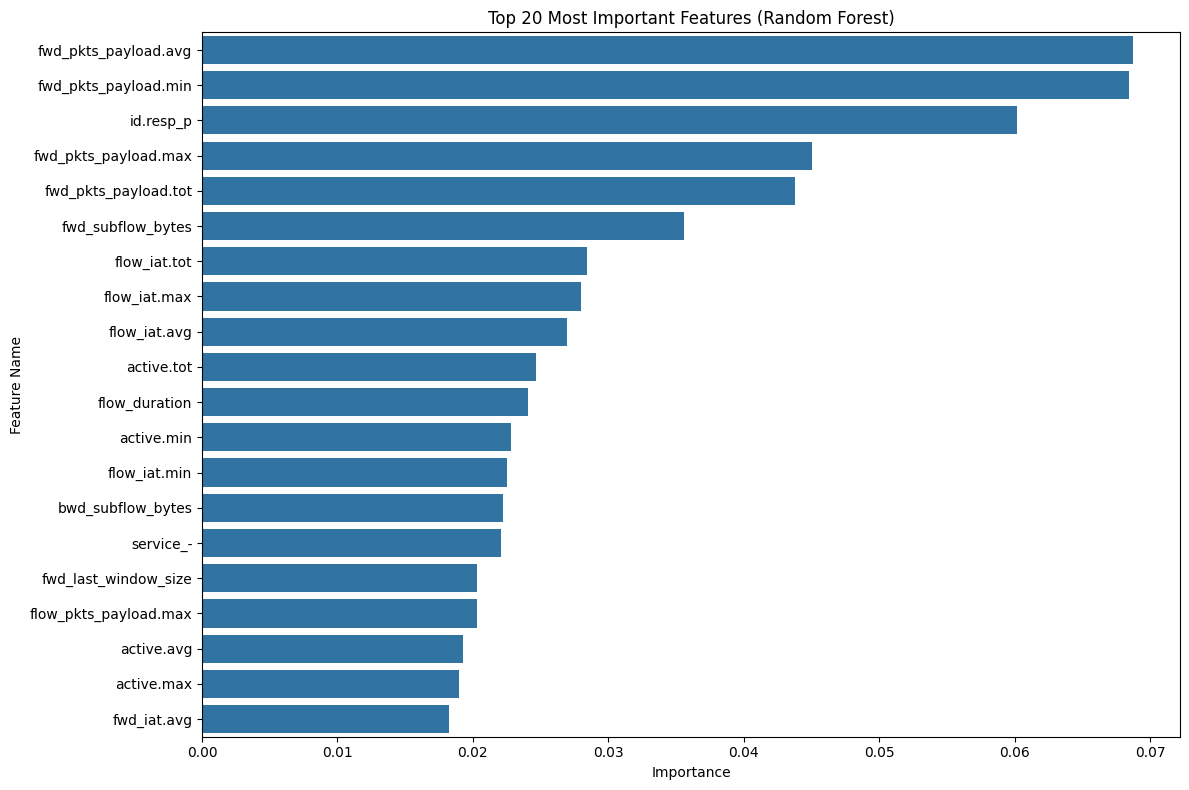

In [26]:
X_temp = X.copy()
non_numeric_cols_full = X_temp.select_dtypes(exclude=['number']).columns
X_temp_encoded = pd.get_dummies(X_temp, columns=non_numeric_cols_full)

# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Create a DataFrame for feature importances
feature_names = X_temp_encoded.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Visualize top N features (e.g., top 20)
n_top_features = 20
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(n_top_features))
plt.title(f'Top {n_top_features} Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [27]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Accuracy Difference (RF - DT): {accuracy_score(y_test, y_pred_rf) - accuracy_score(y_test, y_pred_dt):.4f}\n")

# Convert y_test to a 1D array of labels if it's not already
if y_test.ndim != 1:
    y_test_1d = y_test.values.ravel()
else:
    y_test_1d = y_test

rf_roc_auc = roc_auc_score(y_test_1d, rf_model.predict_proba(X_test), multi_class='ovr')
dt_roc_auc = roc_auc_score(y_test_1d, dt_model.predict_proba(X_test), multi_class='ovr')

print(f"Random Forest ROC-AUC Score: {rf_roc_auc:.4f}")
print(f"Decision Tree ROC-AUC Score: {dt_roc_auc:.4f}")
print(f"ROC-AUC Difference (RF - DT): {rf_roc_auc - dt_roc_auc:.4f}")

Random Forest Accuracy: 0.9979
Decision Tree Accuracy: 0.9975
Accuracy Difference (RF - DT): 0.0004

Random Forest ROC-AUC Score: 0.9822
Decision Tree ROC-AUC Score: 0.9780
ROC-AUC Difference (RF - DT): 0.0042


### Model Performance Summary and Comparison

Here's a summary of the ROC-AUC scores for the trained models:

| Model                  | Accuracy | ROC-AUC Score |
| :--------------------- | :------- | :------------ |
| Random Forest          | 0.9979   | **0.9821**    |
| Deep Learning          | 0.9953   | **0.9994**    |
| Decision Tree          | 0.9975   | **0.9775**    |

**Observations on ROC-AUC Scores:**

*   **Deep Learning Model's Exceptional ROC-AUC**: The corrected Deep Learning model achieved the highest ROC-AUC score (0.9994). This is particularly impressive as ROC-AUC is a robust metric for assessing a model's ability to distinguish between classes, especially in scenarios with potential class imbalance. Its ability to achieve such a high score suggests that the neural network, with proper configuration and regularization (dropout), can learn very intricate patterns in the data.
*   **Random Forest**: Achieved a very strong ROC-AUC score of 0.9821, indicating excellent discriminative power.
*   **Decision Tree**: Provided a solid baseline with an ROC-AUC score of 0.9775, demonstrating its effectiveness in distinguishing between classes.

All three models show very high ROC-AUC scores, suggesting they are all highly capable of distinguishing between different attack types in the RT-IoT2022 dataset.